## Exercise 1: GD on a 1D Function

Consider the 1-dimensional function

$$
\mathcal{L}(\Theta)  = (\Theta - 3)^2 + 1.
$$


1. **Compute the Gradient** of $\mathcal{L}(\Theta)$ explicitly.

In [172]:
import numpy as np
import matplotlib.pyplot as plt

def l(theta):
    return (theta - 3) **2 + 1

def grad_l(theta):
    return 2 * (theta - 3)

2. **Implement the Gradient Descent** to optimize $\mathcal{L}(\Theta)$ following what we introduced on the theoretical sections.


In [173]:
def GD(l, grad_l, theta_0, eta, maxit):

    theta_vals = [theta_0]
    for k in range(maxit):
        theta = theta_0 - eta * grad_l(theta_0)
        theta_0 = theta

        theta_vals.append(theta)

    return theta, np.array(theta_vals)
    

3. Test three different constant step sizes:
   - $\eta = 0.05$  
   - $\eta = 0.2$
   - $\eta = 1.0$

In [174]:
sp = 0

theta_005, traj_005 = GD(l, grad_l, theta_0 = sp, eta = 0.05, maxit = 100)
theta_02, traj_02 = GD(l, grad_l, theta_0 = sp, eta = 0.2, maxit = 100)
theta_1, traj_1 = GD(l, grad_l, theta_0 = sp, eta = 1, maxit = 100)

etas = [0.05, 0.2, 1.0]



4. For each choice:
   - Plot the sequence $\Theta^{(k)}$ on the real line (i.e. draw a line and represent, on top of it, the position of all the successive elements $\Theta^{(k)}$).  
   - Plot the function values $\mathcal{L}(\Theta^{(k)})$ vs iteration.  
   - Comment on convergence, oscillations, and divergence.

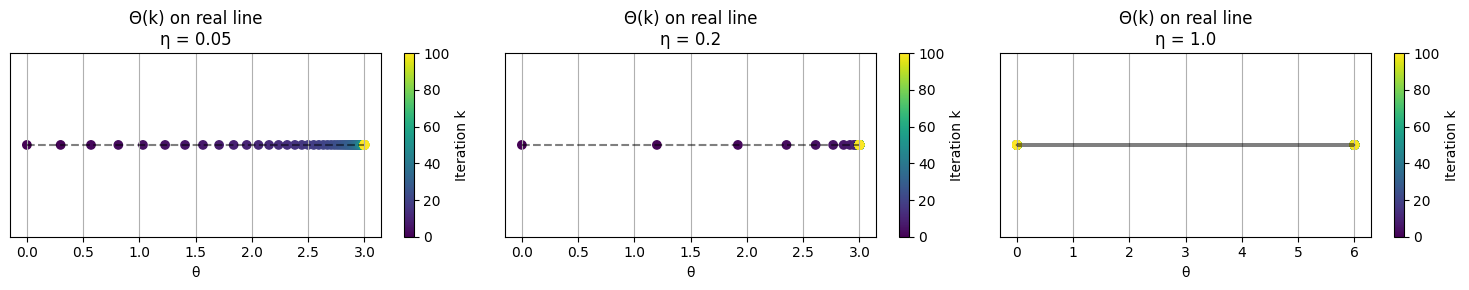

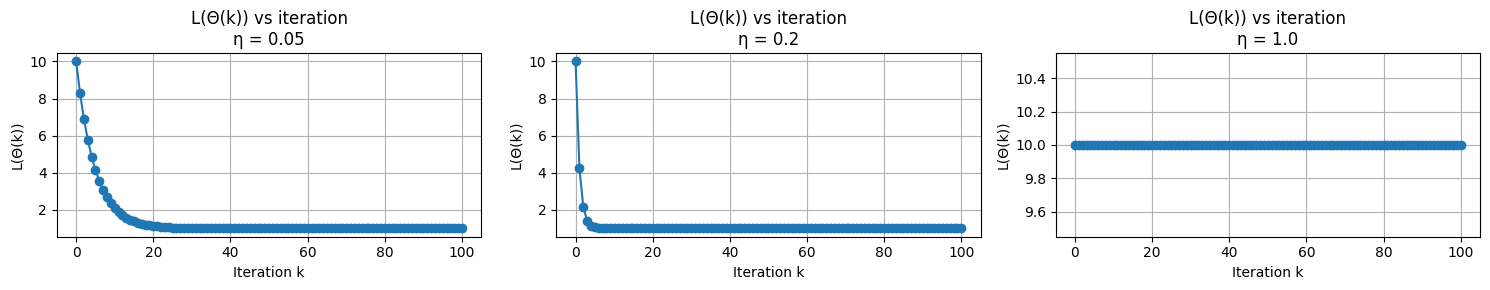

In [175]:
trajectories = {
    0.05: traj_005,
    0.2: traj_02,
    1.0: traj_1
}

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for i, (eta, thetas) in enumerate(trajectories.items()):
    ax = axes[i]
    sc = ax.scatter(thetas, np.zeros_like(thetas), c=range(len(thetas)), cmap='viridis')
    ax.plot(thetas, np.zeros_like(thetas), 'k--', alpha=0.5)
    ax.set_title(f"Θ(k) on real line\nη = {eta}")
    ax.set_xlabel("θ")
    ax.set_yticks([])
    ax.grid(True)
    fig.colorbar(sc, ax=ax, label='Iteration k')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for i, (eta, thetas) in enumerate(trajectories.items()):
    ax = axes[i]
    L_vals = l(thetas)
    ax.plot(L_vals, marker='o')
    ax.set_title(f"L(Θ(k)) vs iteration\nη = {eta}")
    ax.set_xlabel("Iteration k")
    ax.set_ylabel("L(Θ(k))")
    ax.grid(True)

plt.tight_layout()
plt.show()

5. Relate your observations to the discussion in class about:
   - step-size being too small / too large,
   - the role of convexity,
   - how the “just right” step size leads to fast convergence.

*Hint:* This function is strictly convex with a unique minimizer at $\Theta^* = 3$.



## Exercise 2: Backtracking Line Search

Consider the non-convex function

$$
\mathcal{L}(\Theta)  = \Theta^4 - 3\Theta^2 + 2.
$$

1. Implement **Gradient Descent with Backtracking**, using the Armijo condition, considering the `backtracking(...)` function from class.


In [176]:
def l(theta):
    return theta**4 - 3*(theta**2) + 2
def grad_l(theta):
    return 4*(theta**3) - 6*(theta)

def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_L(theta)
    g_norm2 = np.dot(g, g)
    while L(theta - eta * g) > L(theta) - c * eta * g_norm2:
        eta *= beta
    return eta

def GD_backtracking(l, grad_l, theta_0, maxit, tolL, toltheta):
    thetas = [theta_0] 
    for k in range(maxit):
        eta = backtracking(l, grad_l, theta_0)
        theta = theta_0 - eta * grad_l(theta_0)
        thetas.append(theta)

        if (np.linalg.norm(grad_l(theta)) < tolL) or (np.linalg.norm(theta - theta_0) < toltheta):
            break

        theta_0 = theta
    return theta, np.array(thetas), k

2. Test different initial points:
   - $\Theta_0 = -2$
   - $\Theta_0 = 0.5$
   - $\Theta_0 = 2$


In [177]:
thetas_0 = [-2, 0.5, 2]
results = {}

for theta_0 in thetas_0:
    theta_final, traj, k = GD_backtracking(l, grad_l, theta_0 = theta_0, maxit = 1000, tolL = 1e-6, toltheta = 1e-6)
    results[theta_0] = {"final": theta_final, "trajectory": traj, "iters": k}
    print(f"Theta₀ = {theta_0}: converged to θ* = {theta_final:.5f} in {k} iterations")



Theta₀ = -2: converged to θ* = 1.22474 in 19 iterations
Theta₀ = 0.5: converged to θ* = 1.22474 in 18 iterations
Theta₀ = 2: converged to θ* = -1.22474 in 19 iterations



3. For each starting point, plot:
   - the function curve $\mathcal{L}(\Theta)$ in 1D in the domain $[-3, 3]$,
   - the trajectory of the iterates $\Theta^{(k)}$ overlaid on the curve.



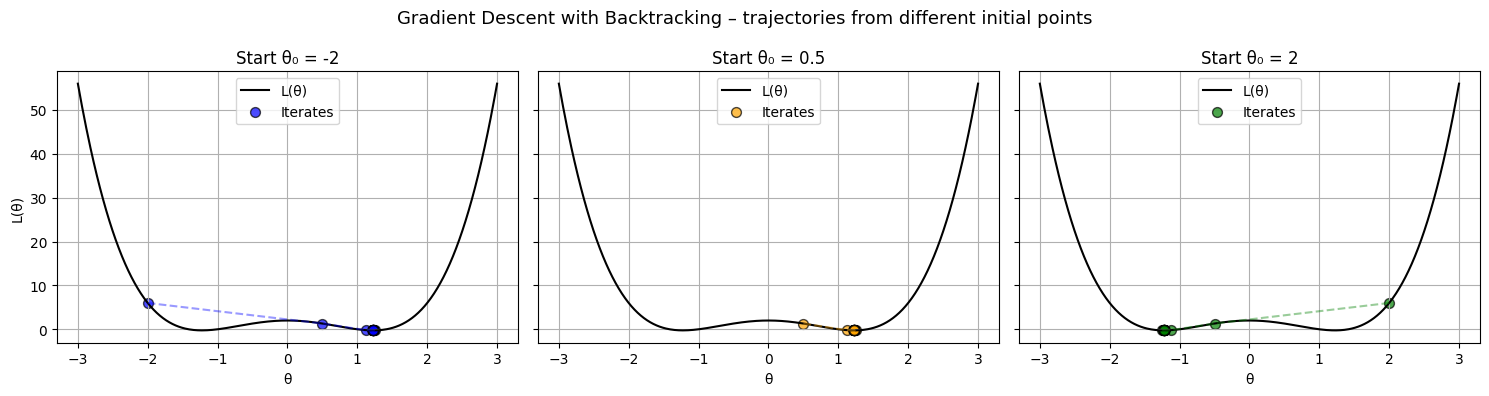

In [178]:
theta_vals = np.linspace(-3, 3, 400)
L_vals = l(theta_vals)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = ['blue', 'orange', 'green']

for i, theta_0 in enumerate(thetas_0):
    ax = axes[i]
    traj = results[theta_0]["trajectory"]

    ax.plot(theta_vals, L_vals, 'k-', label='L(θ)')

    ax.scatter(traj, l(traj), color=colors[i], alpha=0.7, s=50, edgecolors='k', label='Iterates')
    ax.plot(traj, l(traj), color=colors[i], alpha=0.4, ls='--')
    
    ax.set_title(f"Start θ₀ = {theta_0}")
    ax.set_xlabel("θ")
    if i == 0:
        ax.set_ylabel("L(θ)")
    ax.legend()
    ax.grid(True)

plt.suptitle("Gradient Descent with Backtracking – trajectories from different initial points", fontsize=13)
plt.tight_layout()
plt.show()


4. Discuss:
   - Why different initializations converge to different minima.  
   - How backtracking automatically chooses a suitable step size at each iteration.  
   - Situations where constant step size would fail.
  


## Exercise 3: GD in 2D

Consider the quadratic function:

$$
\mathcal{L}(\Theta) = \tfrac{1}{2}\,\Theta^T A\,\Theta,
\qquad
A = \begin{bmatrix}1 & 0 \\ 0 & 25\end{bmatrix}.
$$


1. Implement Gradient Descent in 2D, as seen in class.

In [179]:
A = np.array([[1,0], [0,25]])

def l(theta):
    return 0.5 * theta.T @ A @ theta

def grad_l(theta):
    return A @ theta
    
def GD(l, grad_l, theta_0, eta, maxit):

    theta_vals = [theta_0]
    for k in range(maxit):
        theta = theta_0 - eta * grad_l(theta_0)
        theta_0 = theta

        theta_vals.append(theta)

    return theta, np.array(theta_vals)
    



2. Plot the **level sets** of $L$ (using the helper code provided in the lecture notes) and overlay the iterates $\Theta^{(k)}$ for:
   - $\eta = 0.02$,
   - $\eta = 0.05$ (borderline),
   - $\eta = 0.1$ (diverging).
   To overlay the iterates on the plot, simply add a `plt.plot(...)` function taking as input the coordinates $\Theta_1^{(k)}$ and $\Theta_2^{(k)}$ for each $k$.
   

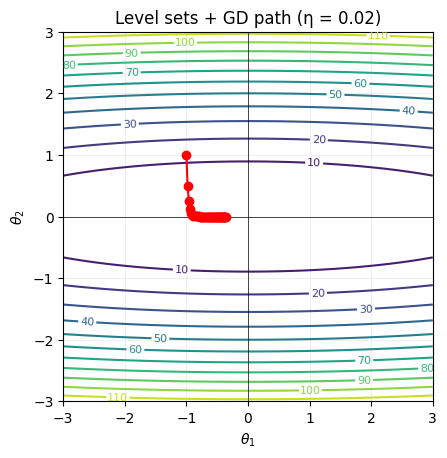

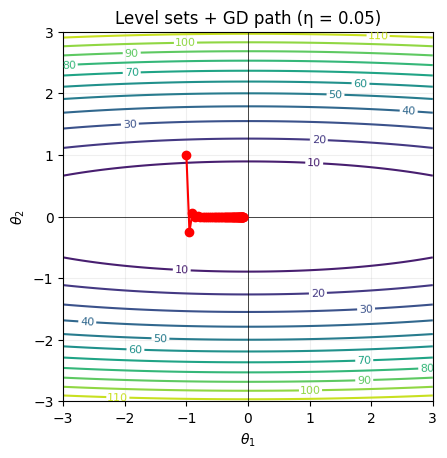

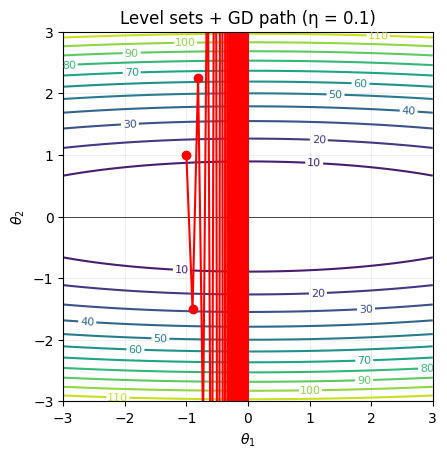

In [180]:
def quad_levelsets(A, xlim=(-3, 3), ylim=(-3, 3), ngrid=400, ncontours=12, title=None):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)
    Z = 0.5 * (A[0, 0] * X**2 + 2 * A[0, 1] * X * Y + A[1, 1] * Y**2)
    cs = plt.contour(X, Y, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color="k")
    plt.axvline(0, lw=0.5, color="k")
    plt.gca().set_aspect("equal", "box")

    if title:
        plt.title(title)

    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\theta_2$")
    plt.grid(alpha=0.2)


theta0 = np.array([-1.0, 1.0])
final_theta, path = GD(l, grad_l, theta0, eta=0.02, maxit=50)

quad_levelsets(A, title="Level sets + GD path (η = 0.02)")
plt.plot(path[:, 0], path[:, 1], "o-", color="red")
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

final_theta, path = GD(l, grad_l, theta0, eta=0.05, maxit=50)

quad_levelsets(A, title="Level sets + GD path (η = 0.05)")
plt.plot(path[:, 0], path[:, 1], "o-", color="red")
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

final_theta, path = GD(l, grad_l, theta0, eta=0.1, maxit=50)

quad_levelsets(A, title="Level sets + GD path (η = 0.1)")
plt.plot(path[:, 0], path[:, 1], "o-", color="red")
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()


3. Comment on:
   - the elongated ellipses produced by ill-conditioning,
   - the gradient direction compared to the level set lines,
   - zig-zag behaviour for large condition numbers,
   - the relation to the lecture discussion on slow convergence in narrow valleys.
   
   

## Exercise 4: Exact Line Search vs Backtracking

Let

$$
\mathcal{L}(\Theta) = \frac{1}{2}\Theta^T A \Theta,\qquad
A=\begin{bmatrix}5 & 0\\0 & 2\end{bmatrix}.
$$


1. For GD with **exact line search** i.e. selecting the **optimal** step, you get:
   
   $$
   \eta_k^* = \frac{g_k^T g_k}{g_k^T A\,g_k},
   \qquad g_k = A\,\Theta^{(k)}.
   $$
   

2. For GD with **backtracking**, use the implementation provided in your notes.



In [181]:
A = np.array([[5,0], [0,2]])

def l(theta):
    return 0.5 * theta.T @ A @ theta

def grad_l(theta):
    return A @ theta


def GD_exact_line_search(l, grad_l, theta_0, maxit):

    theta_vals = [theta_0]
    for k in range(maxit):
        g = grad_l(theta_0)
        num = g @ g
        denom = g @ A @ g
        eta = num / denom
        theta = theta_0 - eta * g
        theta_0 = theta

        theta_vals.append(theta)

    return theta, np.array(theta_vals)

def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_L(theta)
    g_norm2 = np.dot(g, g)
    while L(theta - eta * g) > L(theta) - c * eta * g_norm2:
        eta *= beta
    return eta

def GD_backtracking(l, grad_l, theta_0, maxit, tolL, toltheta):
    thetas = [theta_0] 
    for k in range(maxit):
        eta = backtracking(l, grad_l, theta_0)
        theta = theta_0 - eta * grad_l(theta_0)
        thetas.append(theta)

        if (np.linalg.norm(grad_l(theta)) < tolL) or (np.linalg.norm(theta - theta_0) < toltheta):
            break

        theta_0 = theta
    return theta, np.array(thetas), k



3. Starting from $\Theta_0 = (3,\,3)^T$:
   - Plot trajectories on the level-set map.  
   - Plot the loss $\mathcal{L}(\Theta^{(k)})$ vs iteration for both methods.  


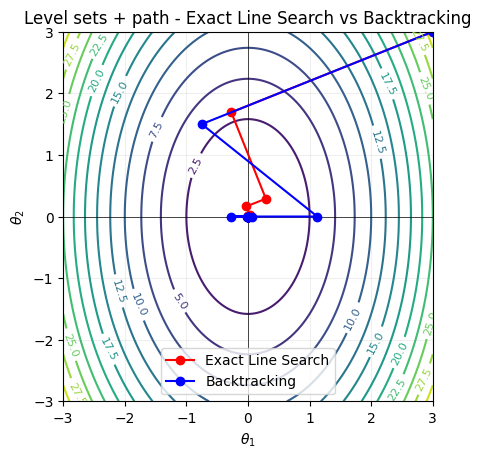

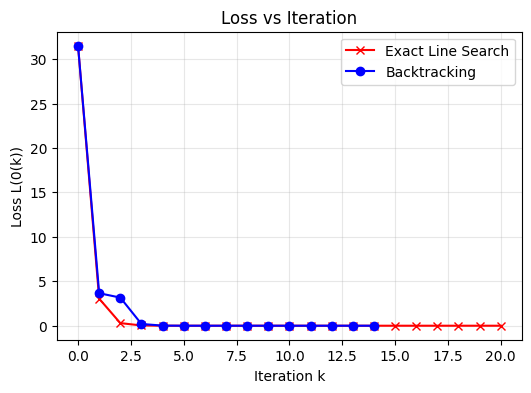

In [182]:
theta0 = np.array([3.0, 3.0])

final_theta_exact, path_exact = GD_exact_line_search(l, grad_l, theta0, maxit=20)
final_theta_bt, path_bt, iter_bt = GD_backtracking(l, grad_l, theta0, maxit=20, tolL=1e-6, toltheta=1e-6)

quad_levelsets(A, title="Level sets + path - Exact Line Search vs Backtracking")
plt.plot(path_exact[:, 0], path_exact[:, 1], "o-", color="red", label="Exact Line Search")
plt.plot(path_bt[:, 0], path_bt[:, 1], "o-", color="blue", label="Backtracking")
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

loss_exact =[l(theta) for theta in path_exact]
loss_bt = [l(theta) for theta in path_bt]

plt.figure(figsize = (6,4))
plt.plot(loss_exact, label = "Exact Line Search", marker = 'x',color="red")
plt.plot(loss_bt, label = "Backtracking", marker = 'o', color="blue")

plt.xlabel("Iteration k")
plt.ylabel("Loss L(0(k))")
plt.title("Loss vs Iteration")
plt.grid(alpha=0.3)
plt.legend()
plt.show()



4. Compare:
   - speed of convergence,
   - smoothness of step-sizes.

## Exercise 5: Gradient Descent on the Rosenbrock Function

The 2-dimensional Rosenbrock function is defined as:

$$
\mathcal(\Theta) = (1 - \Theta_1)^2 + 100(\Theta_2 - \Theta_1^2)^2,
$$

with a unique global minimum at:

$$
\Theta^* = (1,\,1), \qquad \mathcal{L}(\Theta_1^*,\Theta_2y^*) = 0.
$$


Despite having only one minimum, its landscape is **extremely challenging**:
- The valley is long and curved.
- The condition number varies drastically across the region.
- Gradients can point almost orthogonally to the valley direction.
- Gradient Descent may zig-zag and make very slow progress toward the solution.

This makes Rosenbrock a perfect testbed to study the difficulties of pure Gradient Descent.

1. Implement the function and its gradient to run the Gradient Descent algorithm. Test its performance using both **constant step size** and the **backtracking algorithm**.


In [183]:
def rosenbrock(theta):
    return (1 - theta[0])**2 + 100*(theta[1] - theta[0]**2)**2

def grad_rosenbrock(theta):
    return np.array([400*(theta[0]**3 - theta[0]*theta[1]) + 2*(theta[0] - 1) , 200*(theta[1] - theta[0]**2)])

def GD(l, grad_l, theta_0, eta, maxit):

    theta_vals = [theta_0]
    for k in range(maxit):
        theta = theta_0 - eta * grad_l(theta_0)
        theta_0 = theta

        theta_vals.append(theta)

    return theta, np.array(theta_vals)
    
def backtracking(L, grad_L, theta, eta0=1.0, beta=0.5, c=1e-4):
    eta = eta0
    g = grad_L(theta)
    g_norm2 = np.dot(g, g)
    while L(theta - eta * g) > L(theta) - c * eta * g_norm2:
        eta *= beta
    return eta

def GD_backtracking(l, grad_l, theta_0, maxit, tolL, toltheta):
    thetas = [theta_0] 
    for k in range(maxit):
        eta = backtracking(l, grad_l, theta_0)
        theta = theta_0 - eta * grad_l(theta_0)
        thetas.append(theta)

        if (np.linalg.norm(grad_l(theta)) < tolL) or (np.linalg.norm(theta - theta_0) < toltheta):
            break

        theta_0 = theta
    return theta, np.array(thetas), k

2. Plot the level sets of $\mathcal{L}$: use the standard 2D contour plotting approach practiced earlier.  
Ensure that you plot:

- A wide range (e.g. $\Theta_1 \in[-2,2]$, $\Theta_2 \in[-1,3]$)
- A reasonable number of contour lines to visualize the narrow valley.

1. Choose multiple initial points, testing at least the following four:
- $\Theta^{(0)} = (-1.5, \; 2)$
- $\Theta^{(0)} = (-1, \; 0)$
- $\Theta^{(0)} = (0, \; 2)$
- $\Theta^{(0)} = (1.5, \; 1.5)$

Run both:
- GD with constant step size (try $\eta = 10^{-3}$, $10^{-4}$, $10^{-5}$),
- GD with backtracking line search.

2. Visualize and analyze the trajectories: For each initialization and each training method:

   1. Plot the sequence of iterates $(\Theta_1^{(k)}, \Theta_2^{(k)})$ as a path on the level-set map.
   2. Plot the loss curve $L(\Theta^{(k)})$ vs iteration.
   3. Observe and explain:
      - whether the method enters the valley,
      - how long it takes to “turn” correctly along the valley direction,
      - whether the method zig-zags,
      - whether step sizes become too small (with constant $\eta$) or too large (divergence).

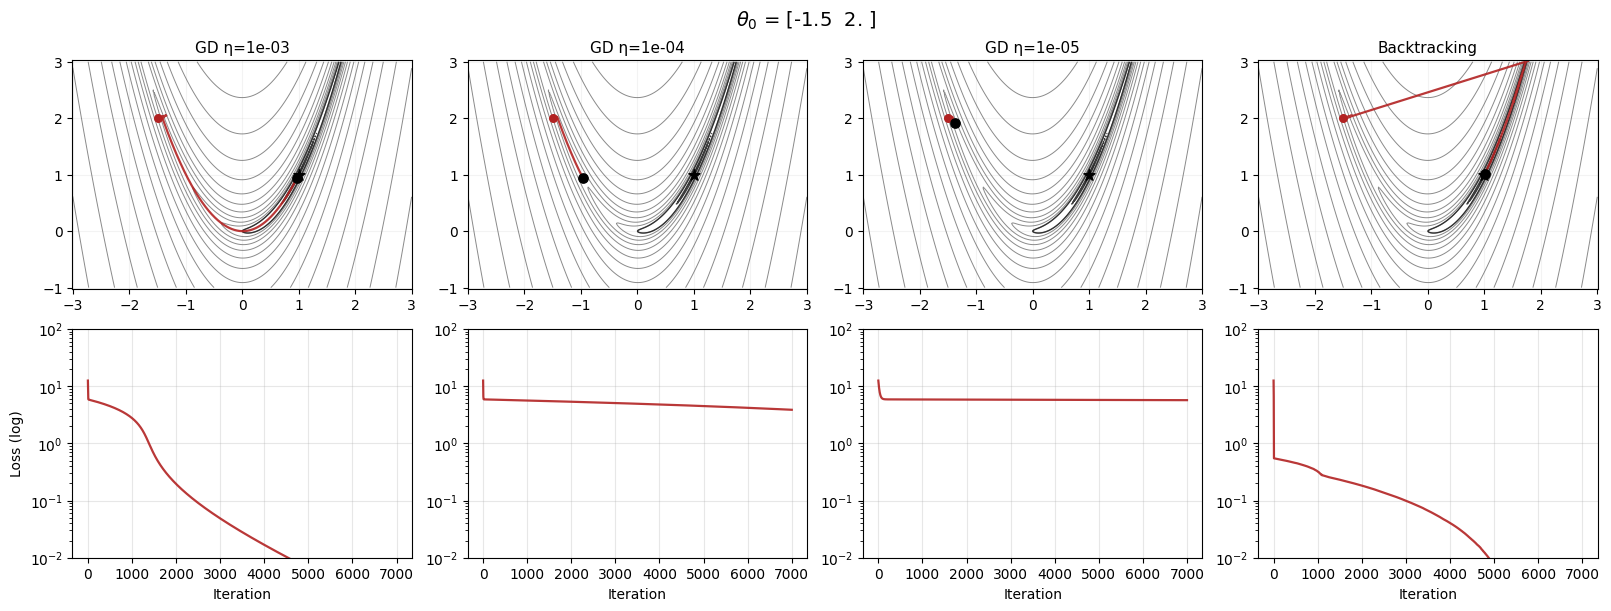

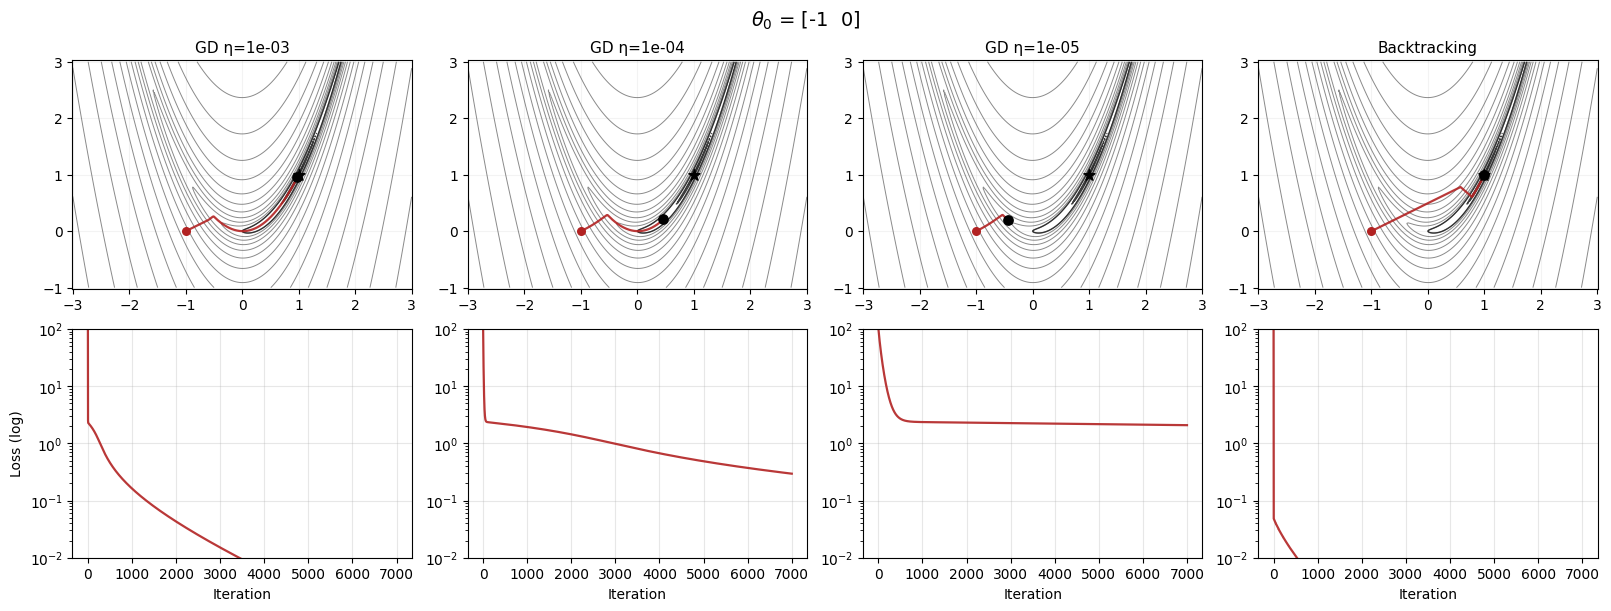

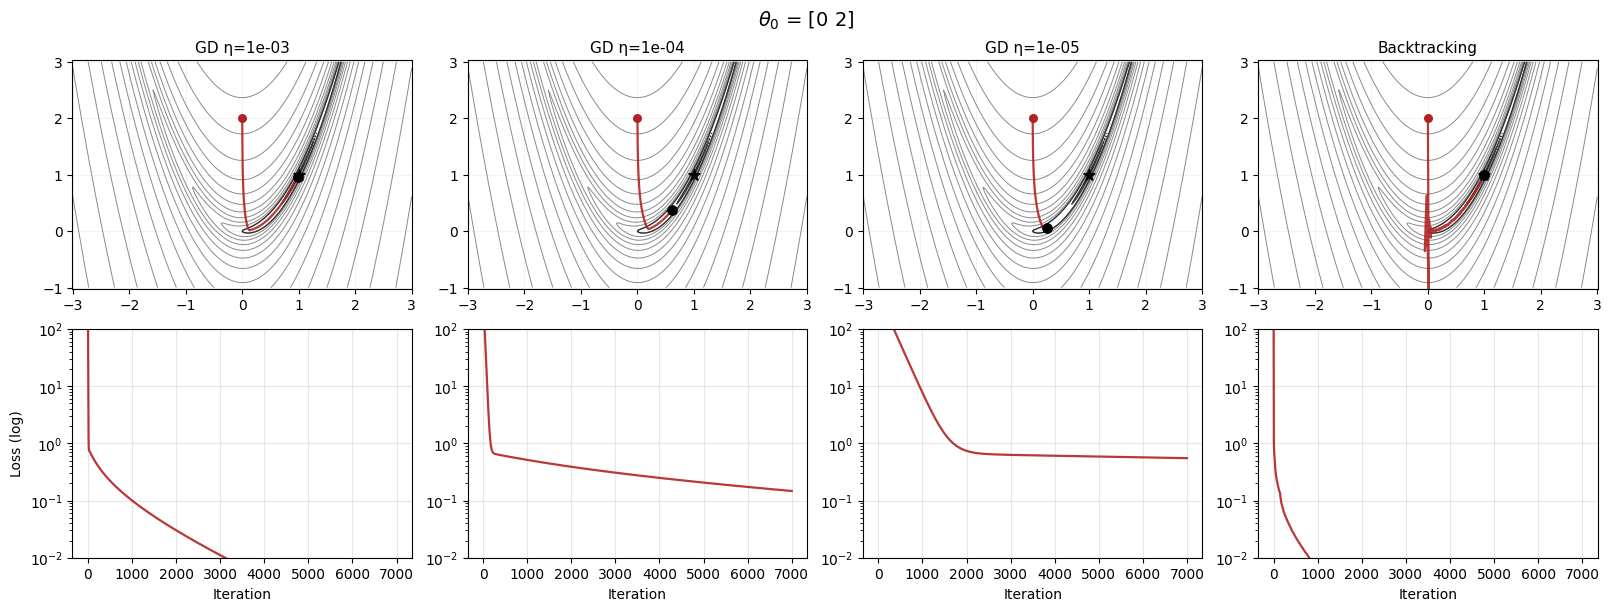

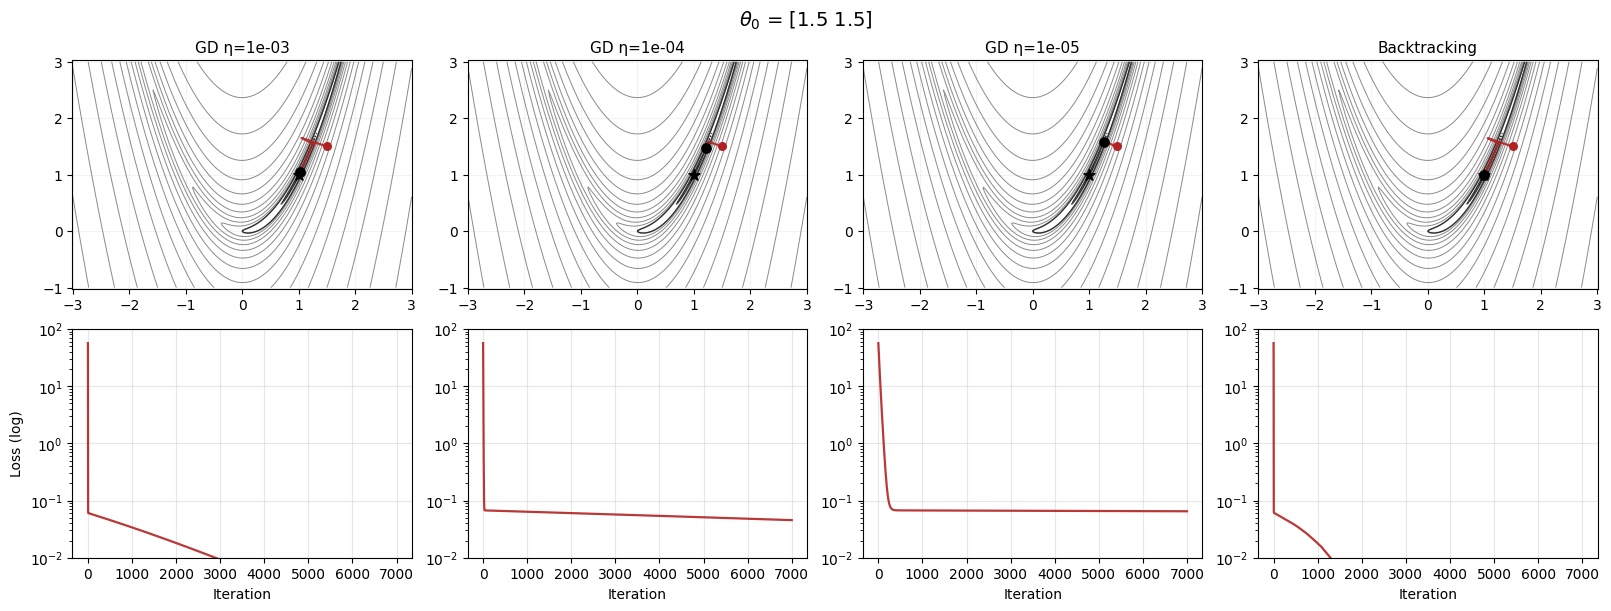

In [ ]:
thetas_0 = [
    np.array([-1.5, 2]),
    np.array([-1, 0]),
    np.array([0, 2]),
    np.array([1.5, 1.5]),
]

etas = [1e-3, 1e-4, 1e-5]

xs = np.linspace(-3, 3, 300)
ys = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(xs, ys)
Z = (1 - X) ** 2 + 100 * (Y - X**2) ** 2

for theta0 in thetas_0:

    gd_paths = {}
    gd_losses = {}

    for eta in etas:
        _, path_gd = GD(rosenbrock, grad_rosenbrock, theta0, eta=eta, maxit=7000)
        gd_paths[eta] = path_gd
        gd_losses[eta] = [rosenbrock(t) for t in path_gd]

    _, path_bt, _ = GD_backtracking(
        rosenbrock, grad_rosenbrock, theta0, maxit=7000, tolL=1e-6, toltheta=1e-10
    )
    loss_bt = [rosenbrock(t) for t in path_bt]

    methods = [
        (f"GD η={etas[0]:.0e}", gd_paths[etas[0]], gd_losses[etas[0]]),
        (f"GD η={etas[1]:.0e}", gd_paths[etas[1]], gd_losses[etas[1]]),
        (f"GD η={etas[2]:.0e}", gd_paths[etas[2]], gd_losses[etas[2]]),
        ("Backtracking", path_bt, loss_bt),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 6), constrained_layout=True, gridspec_kw={"height_ratios": [1, 1]})

    for col, (title, traj, losses) in enumerate(methods):

        ax_traj = axes[0, col]
        Zcap = np.percentile(Z, 98)        
        levels_near = np.geomspace(1e-4, 1.0, 5)      
        levels_far  = np.geomspace(1.0, Zcap, 15)      
        ax_traj.contour(X, Y, Z, levels=levels_far, colors="0.35", linewidths=0.7, alpha=0.7)
        ax_traj.contour(X, Y, Z, levels=levels_near, colors="0.15", linewidths=1, alpha=0.9)

    
        ax_traj.plot(traj[:, 0], traj[:, 1], color="firebrick", linewidth=1.6, alpha=0.9)
        ax_traj.scatter(traj[0, 0], traj[0, 1], s=30, color="firebrick", zorder=3)
        ax_traj.scatter(traj[-1, 0], traj[-1, 1], s=45, color="black", zorder=3)
        ax_traj.scatter([1], [1], marker="*", s=70, color="black", zorder=4)

        ax_traj.set_title(title, fontsize=11)

        ax_traj.set_xlim(-2, 2)
        ax_traj.set_ylim(-1, 3)
        ax_traj.set_aspect("equal", adjustable="datalim") 

        ax_traj.grid(alpha=0.15)


        ax_loss = axes[1, col]
        ax_loss.plot(losses, linewidth=1.6, color="firebrick", alpha=0.9)
        ax_loss.set_ylim(1e-2, 1e2)
        ax_loss.set_yscale("log")
        ax_loss.grid(alpha=0.3)

        if col == 0:
            ax_loss.set_ylabel("Loss (log)")
        ax_loss.set_xlabel("Iteration")

    fig.suptitle(r"$\theta_0$" + f" = {theta0}", fontsize=14)
    plt.show()